In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# This is for the graph visualization
from graphviz import Digraph

In [2]:
#starting the Project
class Value:
    def __init__(self,data,_children=(),_op='',label = ''):
      self._prev = set(_children)
      self.data = data
      self._op = _op
      self.grad = 0.0
      self._backward = lambda : None
      self.label = label
    def __repr__(self):
      return f"Value(data = {self.data})"
    def __add__(self,other):
      out = Value(self.data + other.data,(self,other),'+')
      def _backward():
        self.grad = 1 * out.grad
        other.grad = 1 * out.grad
      out._backward = _backward
      return out
    def __mul__(self,other):
      out = Value(self.data * other.data,(self,other),'*')
      def _backward():
        self.grad = other.data * out.grad
        other.grad = self.data * out.grad
      out._backward = _backward
      return out
    def tanh(self):
      x = self.data
      t = (math.exp(2*x)-1)/ (math.exp(2*x)+1)
      out = Value(t,(self,),'tanh')
      def _backward():
        self.grad = (1-t**2) * out.grad
      out._backward = _backward
      return out
    #Define backward the Recursivee Function
    def backward(self):
      #Create empty lest topo and the empty set visited
      topo = []
      visited = set()
      #Create Build TOPO function to append to it the children
      def build_topo(v):
        #check if we already looped over v
        if v not in visited:
            #I should add it for the next time
            visited.add(v)
            #Recursion Time
            for child in v._prev:
              build_topo(child)
            topo.append(v)
      #NOW WE BUILD THE TOPO OF THE OUTPUT LAYER
      build_topo(self)
      self.grad = 1 #THE DERIVATIVE OF THE OUTPUT LAYER WITH RESPECT TO ITSELF IS ALWAYS 1
      for node in reversed(topo): # we use Reversed because the output layer will be in the end of topo but we need to start with it
        node._backward()   #Now We calclate the grade from the end to start
    


In [3]:
# X values
x1 = Value(2.0 ,label='x1')
x2 = Value(0.0 ,label='x2')
# Weights
w1 = Value(-5.0,label='w1')
w2 = Value(1.0,label='w2')
# Bias
b = Value(6.689999921304,label='b')
# The Function
w1x1 = w1 * x1;w1x1.label='w1 * x1'
w2x2 = w2 * x2;w2x2.label='w2 * x2'
w1x1w2x2 = w1x1 + w2x2;w1x1w2x2.label = 'w1*x1 + w2*x2'
n = w1x1w2x2 + b;n.label='n'
o = n.tanh();o.label='o'

In [4]:
from graphviz import Digraph

def trace(root):
    # Builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Create a rectangular ('record') node for every Value in the graph
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data,n.grad), shape='record')

        if n._op:
            # If this value is a result of an operation (+ or *), create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # Connect the op node to the actual Value node
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # Connect the child node to the op node of its parent
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

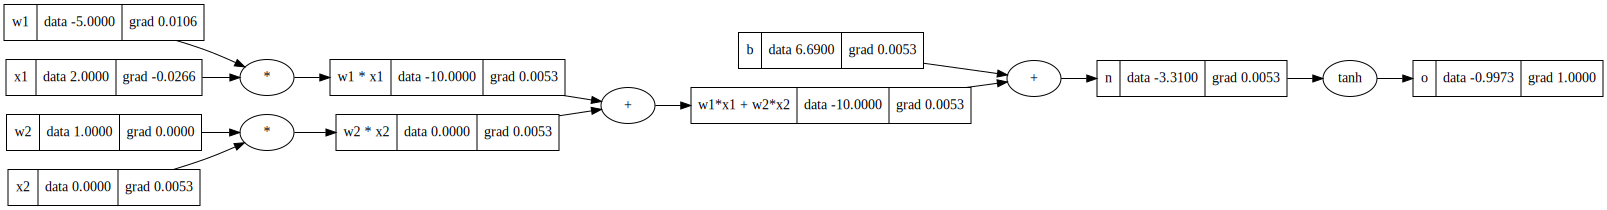

In [5]:

o.backward()
draw_dot(o)